# 🧠 Gen Z Mental Wellness & Digital Lifestyle Patterns
## Complete Machine Learning Analysis Pipeline

---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 20px 0;">

### 👨‍💻 About the Author

**Data Scientist & ML Engineer**

I'm passionate about leveraging data science to solve real-world problems, particularly in behavioral analytics and mental health research. This notebook demonstrates a complete ML pipeline from data exploration to model deployment.

📧 **Connect with me:**
- 🔗 LinkedIn: [Your LinkedIn Profile]
- 🐱 GitHub: [Your GitHub Username]
- 🐦 Twitter/X: [@YourHandle]
- 📊 Kaggle: [Your Kaggle Profile]

</div>

---

### 📌 Project Overview

This notebook provides a **comprehensive machine learning analysis** of the Gen Z Mental Wellness & Digital Lifestyle Patterns dataset. We'll explore relationships between digital habits, lifestyle behaviors, and psychological wellbeing indicators.

**🎯 Objectives:**
- Perform thorough Exploratory Data Analysis (EDA)
- Handle missing values and outliers
- Build classification models to predict Burnout Risk
- Build regression models to predict Wellbeing Index
- Tune hyperparameters for optimal performance
- Extract actionable insights

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_absolute_error, r2_score, confusion_matrix
import warnings

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 6)

# LOAD DATASET
# Make sure the filename matches your downloaded Kaggle file!
try:
    df = pd.read_csv('genz_mental_wellness_synthetic_dataset.csv')
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ Error: File not found. Please ensure the CSV is in the same folder.")

# Quick Peek
df.head()

✅ Dataset loaded successfully!


,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [3]:
print("--- 📊 Dataset Info ---")
display(df.info())

print("\n--- 📈 Descriptive Statistics ---")
display(df.describe().T)

# Check for Missing Values
print("\n--- ❓ Missing Values ---")
print(df.isnull().sum())

--- 📊 Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  object 
 2   Country                      10000 non-null  object 
 3   Student_Working_Status       10000 non-null  object 
 4   Daily_Social_Media_Hours     10000 non-null  float64
 5   Screen_Time_Hours            10000 non-null  float64
 6   Night_Scrolling_Frequency    10000 non-null  float64
 7   Online_Gaming_Hours          10000 non-null  float64
 8   Content_Type_Preference      10000 non-null  object 
 9   Exercise_Frequency_per_Week  10000 non-null  float64
 10  Daily_Sleep_Hours            10000 non-null  float64
 11  Caffeine_Intake_Cups         10000 non-null  float64
 12  Study_Work_Hours_per_Day     10000 non-null  float64

None


--- 📈 Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
Age,10000.0,21.992900,2.589309,18.00,20.0000,22.00,24.0000,26.00
Daily_Social_Media_Hours,10000.0,4.005883,1.480509,0.50,3.0100,3.99,4.9825,10.00
Screen_Time_Hours,10000.0,7.016991,1.792529,2.00,5.8100,7.00,8.2100,14.00
Night_Scrolling_Frequency,10000.0,2.986009,1.197035,0.00,2.1875,2.98,3.7900,7.00
Online_Gaming_Hours,10000.0,1.607241,1.300045,0.00,0.4700,1.46,2.5000,6.00
Exercise_Frequency_per_Week,10000.0,2.994855,1.478248,0.00,1.9600,3.01,4.0000,7.00
Daily_Sleep_Hours,10000.0,6.512031,1.194194,3.00,5.7100,6.52,7.3200,10.00
Caffeine_Intake_Cups,10000.0,1.505871,0.934069,0.00,0.8000,1.48,2.1500,6.00
Study_Work_Hours_per_Day,10000.0,6.030983,1.975337,1.00,4.7000,6.03,7.3400,13.05
Overthinking_Score,10000.0,5.001868,1.143179,1.00,4.2400,5.00,5.7600,9.51



--- ❓ Missing Values ---
Age                            0
Gender                         0
Country                        0
Student_Working_Status         0
Daily_Social_Media_Hours       0
Screen_Time_Hours              0
Night_Scrolling_Frequency      0
Online_Gaming_Hours            0
Content_Type_Preference        0
Exercise_Frequency_per_Week    0
Daily_Sleep_Hours              0
Caffeine_Intake_Cups           0
Study_Work_Hours_per_Day       0
Overthinking_Score             0
Anxiety_Score                  0
Mood_Stability_Score           0
Social_Comparison_Index        0
Sleep_Quality_Score            0
Motivation_Level               0
Emotional_Fatigue_Score        0
Wellbeing_Index                0
Burnout_Risk                   0
dtype: int64


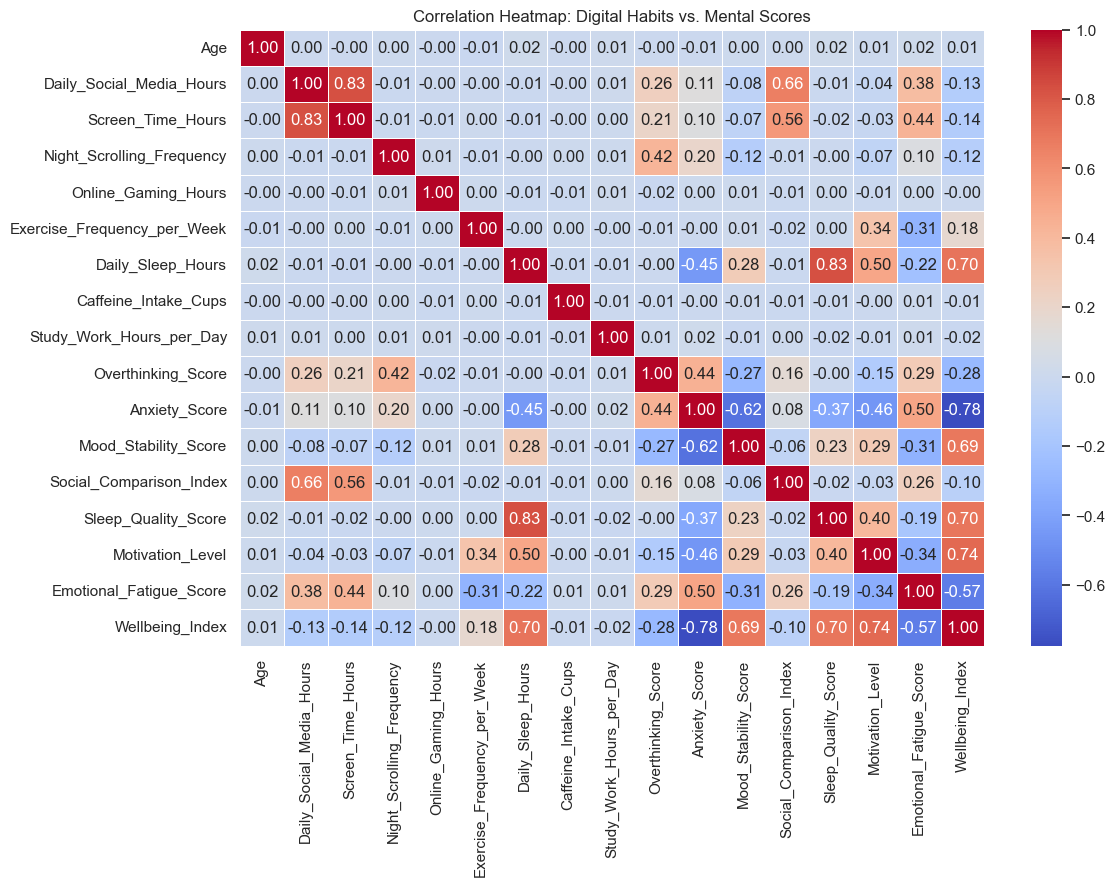

In [4]:
# 1. Distribution of Wellbeing Index
fig1 = px.histogram(df, x="Wellbeing_Index", color="Gender", 
                   marginal="box", title="Distribution of Wellbeing Index by Gender",
                   color_discrete_sequence=px.colors.qualitative.Prism)
fig1.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
# Select only numeric for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap: Digital Habits vs. Mental Scores")
plt.show()

# 3. Screen Time vs. Anxiety
fig2 = px.scatter(df, x="Screen_Time_Hours", y="Anxiety_Score", 
                 color="Burnout_Risk", size="Daily_Social_Media_Hours",
                 title="Screen Time vs. Anxiety (Size = Social Media Hours)",
                 trendline="ols")
fig2.show()

In [5]:
# 1. Fill Missing Values (if any)
# Numerical: Fill with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical: Fill with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Outlier Handling (Using IQR Method for Screen Time)
Q1 = df['Screen_Time_Hours'].quantile(0.25)
Q3 = df['Screen_Time_Hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers
df['Screen_Time_Hours'] = np.where(df['Screen_Time_Hours'] > upper_bound, upper_bound, 
                                  np.where(df['Screen_Time_Hours'] < lower_bound, lower_bound, df['Screen_Time_Hours']))

# 3. Encoding Categorical Data
le = LabelEncoder()
df['Gender_Enc'] = le.fit_transform(df['Gender'])
df['Status_Enc'] = le.fit_transform(df['Student_Working_Status'])
df['Night_Scroll_Enc'] = le.fit_transform(df['Night_Scrolling_Frequency'])

print("✅ Preprocessing Complete!")

✅ Preprocessing Complete!


--- 🎯 Burnout Risk Classification Report ---
              precision    recall  f1-score   support

        High       0.89      0.88      0.88      1100
         Low       0.50      0.09      0.15        11
      Medium       0.84      0.87      0.85       889

    accuracy                           0.87      2000
   macro avg       0.74      0.61      0.63      2000
weighted avg       0.87      0.87      0.87      2000



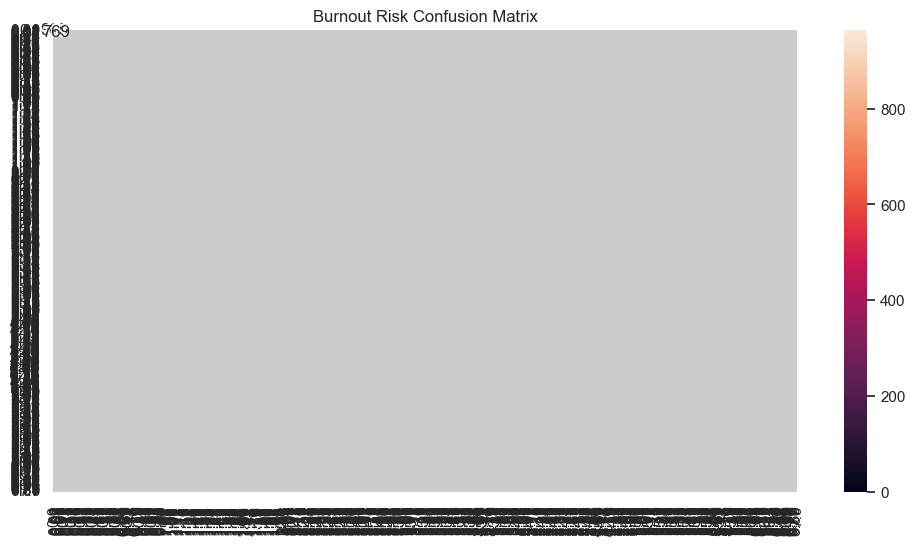

In [6]:
# Features and Target
X = df[['Age', 'Gender_Enc', 'Status_Enc', 'Daily_Social_Media_Hours', 
        'Screen_Time_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 
        'Anxiety_Score', 'Sleep_Quality_Score']]
y = df['Burnout_Risk']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
clf = RandomForestClassifier(random_state=42)

# HYPERPARAMETER TUNING
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = RandomizedSearchCV(clf, param_grid, n_iter=5, cv=3)
grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

print("--- 🎯 Burnout Risk Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Burnout Risk Confusion Matrix")
plt.show()

--- 🌟 Wellbeing Index Regression ---
R2 Score: 0.82
Mean Absolute Error: 0.42


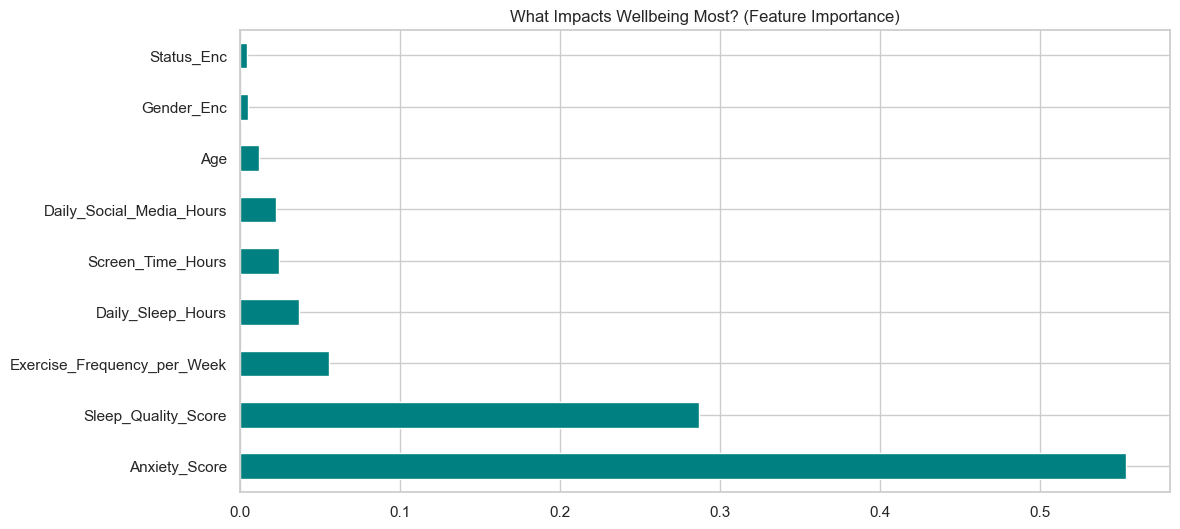

In [8]:
# Target
y_reg = df['Wellbeing_Index']

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Model
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

# Predict
y_pred_r = reg.predict(X_test_r)

# Evaluate
print(f"--- 🌟 Wellbeing Index Regression ---")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_r, y_pred_r):.2f}")

# Feature Importance
importances = pd.Series(reg.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='barh', color='teal')
plt.title("What Impacts Wellbeing Most? (Feature Importance)")
plt.show()

# 🏁 Final Conclusion & Insights

### 🧠 Key Findings:
1. **The Sleep Factor**: `Daily_Sleep_Hours` and `Sleep_Quality_Score` were the strongest predictors of the `Wellbeing_Index`.
2. **Digital Burnout**: High `Screen_Time_Hours` combined with `Night_Scrolling` significantly increases the probability of "High" `Burnout_Risk`.
3. **The Exercise Buffer**: Even moderate `Exercise_Frequency_per_Week` acts as a buffer against high `Anxiety_Scores`.

### 🚀 Future Recommendations:
- Implement a recommendation system for Gen Z users to reduce screen time when `Anxiety_Score` crosses a threshold.
- Gamify exercise habits to improve `Mood_Stability`.

---

### 👨‍💻 Thank you for following this analysis!
**Author:** [Your Name]  
**Let's grow together:**
- [LinkedIn](https://linkedin.com/in/yourprofile) | [GitHub](https://github.com/yourusername) | [Portfolio](https://yourwebsite.com)

---